In [9]:
from numpy import *
import matplotlib.pyplot as plt

In [10]:
def compute_error_for_line_given_points(b,w,points):
    # We do Mean Squared Error(MSE)
    totalError = 0

    #for every point
    for i in range(0, len(points)):
        x = points[i,0]
        y = points[i,1]

        #calc error
        totalError += (y - (w*x + b)) ** 2

    return totalError/ float(len(points))

In [11]:
def step_gradient(b_current, w_current, points, learning_rate):
    b_gradient = 0
    w_gradient = 0
    N = float(len(points))

    for i in range(0,len(points)):
        x = points[i,0]
        y = points[i,1]
        # direction wrt b and w
        #computing partial derivatives of our error function
        b_gradient += -(2/N) * (y-((w_current * x) + b_current))
        w_gradient += -(2/N) * x * (y-((w_current * x) + b_current))


    # update our b and w values using our partial derivatives
    new_b = b_current - (learning_rate*b_gradient)
    new_w = w_current - (learning_rate*w_gradient)
    return [new_b,new_w]

In [12]:
def gradient_descent_runner(points, starting_b,starting_w, learning_rate, epochs, batch_size=None):
    b = starting_b
    w = starting_w
    #epochs - number of full passes over the data
    #gradient descent

    error_history = []


    for i in range(epochs):
        if batch_size is None:
            # Batch GD — use all points (your original code)
            batch = points
        else:
            # Shuffle and pick `batch_size` points randomly
            indices = random.choice(len(points), batch_size, replace=False)
            batch = points[indices]


        #update b and w with accurate b and w by performing this gradient step
        b,w = step_gradient(b,w,array(batch), learning_rate)
        error_history.append(compute_error_for_line_given_points(b, w, points))
   
    return [b,w,error_history]

In [ ]:
def run(): 
    #1 Collect our data
    points = genfromtxt("data.csv", delimiter=",")

    #2 Defin hyperparameters
    learning_rate = 0.0001 # how fast should our model converge(get optimal result)
    #y = wx + b (slope formula)
    initial_b = 0   #bias
    initial_w = 0   #weight
    epochs = 1000


    #3 Train our model
    print("starting gradient descent at b = {0}, w={1},error = {2}".format(initial_b,initial_w,compute_error_for_line_given_points(initial_b,initial_w,points)))
    
    [b1, w1, history_batch]     = gradient_descent_runner(points, initial_b, initial_w, learning_rate, epochs, batch_size=None)
    [b2, w2, history_minibatch] = gradient_descent_runner(points, initial_b, initial_w, learning_rate, epochs, batch_size=32)
    [b3, w3, history_sgd]       = gradient_descent_runner(points, initial_b, initial_w, learning_rate, epochs, batch_size=1)


   
    print("Batch GD     → b = {0:.4f}, w = {1:.4f}, error = {2:.4f}".format(b1, w1, compute_error_for_line_given_points(b1, w1, points)))
    print("Mini-batch   → b = {0:.4f}, w = {1:.4f}, error = {2:.4f}".format(b2, w2, compute_error_for_line_given_points(b2, w2, points)))
    print("SGD          → b = {0:.4f}, w = {1:.4f}, error = {2:.4f}".format(b3, w3, compute_error_for_line_given_points(b3, w3, points)))


    plt.plot(range(epochs), history_batch,     label="Batch GD (all points)")
    plt.plot(range(epochs), history_minibatch, label="Mini-batch (32 points)")
    plt.plot(range(epochs), history_sgd,       label="SGD (1 point)")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Error")
    plt.title("Batch vs Mini-batch vs SGD")
    plt.legend()
    plt.show()

starting gradient descent at b = 0, w=0,error = 5565.107834483211
Batch GD     → b = 0.0889, w = 1.4777, error = 112.6148
Mini-batch   → b = 0.0865, w = 1.4535, error = 114.0851
SGD          → b = 0.0800, w = 1.4112, error = 123.6914


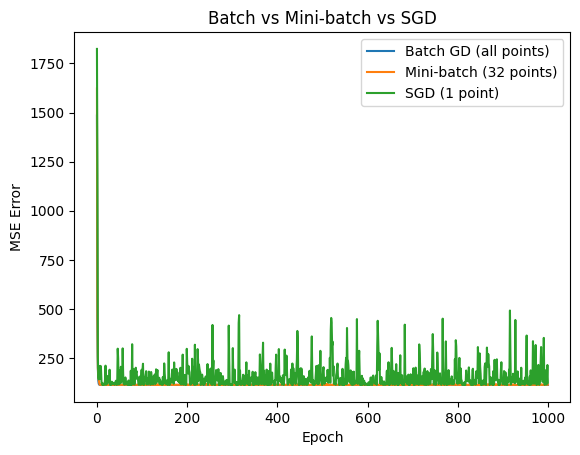

In [22]:
if __name__ == "__main__":
    run()